# Modeling – Asthma Control

Modeling pipeline for predicting poor control in asthma patients.

**Input:** `data_processed.csv` (dataset after EDA)

**Structure:**
1. Imports and data loading
2. Temporal split
3. Encoding
4. Training
5. Baseline Evaluation
6. SHAP Analysis
7. Removal of Features with Zero Importance
8. Hyperparameter tuning with Optuna
9. Final Evaluation on Test
10. Probability Calibration
11. Model Saving

## 1. Imports & data loading

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('data_processed.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (304483, 39)


,area,ap_zone,sex,year,age,arterial_hypertension,chronic_kidney_disease,cardiovascular_disease,obesity,heart_failure,...,biologic_treatment_lag1,pulmonology_follow_up_lag1,allergy_follow_up_lag1,spirometry_lag1,prick_test_lag1,feno_lag1,eos_level_lag1,ige_level_lag1,poor_control_acum,years_in_record
0,area_santander,el_alisal,0,2018,61,0,0,0,0,0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,no_history,no_history,-1,0
1,area_santander,el_alisal,0,2019,62,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,no_analitics,no_analitics,0,1
2,area_santander,el_alisal,0,2020,63,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,no_analitics,no_analitics,0,2
3,area_santander,el_alisal,0,2021,64,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,normal,no_analitics,0,3
4,area_santander,el_alisal,0,2022,65,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,normal,no_analitics,0,4


## 2. Temporal split

A **temporal split** is mandatory for time-series clinical data. A random split would leak future
information into training and produce optimistically biased metrics.

| Split | Years | N | Poor-control rate |
|-------|-------|---|-------------------|
| Train | 2018–2022 | ~210k | 14.5% |
| Validation | 2023 | ~46k | 18.4% |
| Test | 2024 | ~48k | 17.9% |

`year` is excluded from features — it is temporal metadata, not predictive signal available at inference time.

**Note:** The EDA showed an increasing trend in the poor control rate (13% in 2018 → 18% in 2024). This means the model will see a slightly different distribution in the test set than in the training data, which may affect the final metrics.

In [19]:
# Separate features and target before the split
# 'year' is excluded from features: it is temporal information, not predictive in production
TARGET  = 'poor_control'
EXCLUDE = ['year']

features = [c for c in df.columns if c not in [TARGET] + EXCLUDE]

print(f'Nº features: {len(features)}')
print(features)

Nº features: 37
['area', 'ap_zone', 'sex', 'age', 'arterial_hypertension', 'chronic_kidney_disease', 'cardiovascular_disease', 'obesity', 'heart_failure', 'rhinitis_sinusitis_polyposis', 'diabetes', 'osteoporosis', 'osa', 'anxiety', 'depression', 'gastroesophageal_reflux', 'spirometry', 'prick_test', 'feno', 'pulmonology_follow_up', 'allergy_follow_up', 'ics_laba', 'biologic_treatment', 'eos_level', 'ige_level', 'poor_control_lag1', 'ics_laba_lag1', 'biologic_treatment_lag1', 'pulmonology_follow_up_lag1', 'allergy_follow_up_lag1', 'spirometry_lag1', 'prick_test_lag1', 'feno_lag1', 'eos_level_lag1', 'ige_level_lag1', 'poor_control_acum', 'years_in_record']


In [20]:
# Split temporal
train = df[df['year'] <= 2022]
val   = df[df['year'] == 2023]
test  = df[df['year'] == 2024]

X_train, y_train = train[features], train[TARGET]
X_val,   y_val   = val[features],   val[TARGET]
X_test,  y_test  = test[features],  test[TARGET]

print(f'Train: {X_train.shape} | poor_control: {y_train.mean():.2%}')
print(f'Val:   {X_val.shape}   | poor_control: {y_val.mean():.2%}')
print(f'Test:  {X_test.shape}  | poor_control: {y_test.mean():.2%}')

Train: (209992, 37) | poor_control: 14.53%
Val:   (46386, 37)   | poor_control: 18.38%
Test:  (48105, 37)  | poor_control: 17.91%


## 3. Encoding

| Variable type | Columns | Strategy |
|---------------|---------|----------|
| High-cardinality categorical | `area`, `ap_zone` | Target encoding (fit on train only) |
| Ordinal categorical (string) | `eos_level`, `ige_level`, their lags | One-hot encoding |
| Binary (0/1) | All others | No transformation needed |

Target encoding is fit **only on train** to avoid leakage. Unseen categories at inference time receive the global mean.

In [21]:
# Target encoding for high-cardinality variables
# We compute the poor_control rate per category only on the training set
target_encode_cols = ['area', 'ap_zone']

target_encoders = {}
global_mean = y_train.mean()

for col in target_encode_cols:
    mapping = train.groupby(col)[TARGET].mean()
    target_encoders[col] = mapping
    # Unseen categories in the training set receive the global mean
    X_train[col] = X_train[col].map(mapping).fillna(global_mean)
    X_val[col]   = X_val[col].map(mapping).fillna(global_mean)
    X_test[col]  = X_test[col].map(mapping).fillna(global_mean)

print('Applied Target encoding:')
for col in target_encode_cols:
    print(f'  {col}: {len(target_encoders[col])} categorías')

Applied Target encoding:
  area: 5 categorías
  ap_zone: 42 categorías


In [22]:
# One-hot encoding for low-cardinality variables (strings)
# Includes the original variables and their lags
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ['eos_level', 'ige_level', 'eos_level_lag1', 'ige_level_lag1']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[ohe_cols])

def apply_ohe(X, ohe, ohe_cols):
    encoded    = ohe.transform(X[ohe_cols])
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(ohe_cols), index=X.index)
    return pd.concat([X.drop(columns=ohe_cols), encoded_df], axis=1)

X_train = apply_ohe(X_train, ohe, ohe_cols)
X_val   = apply_ohe(X_val,   ohe, ohe_cols)
X_test  = apply_ohe(X_test,  ohe, ohe_cols)

print('Applied One-hot encoding:')
print(f'  Columns generated: {ohe.get_feature_names_out(ohe_cols).tolist()}')
print(f'\nShape final train: {X_train.shape}')
print(f'Shape final val:   {X_val.shape}')
print(f'Shape final test:  {X_test.shape}')

Applied One-hot encoding:
  Columns generated: ['eos_level_high', 'eos_level_moderate', 'eos_level_no_analitics', 'eos_level_normal', 'eos_level_very_high', 'ige_level_high', 'ige_level_no_analitics', 'ige_level_normal', 'eos_level_lag1_high', 'eos_level_lag1_moderate', 'eos_level_lag1_no_analitics', 'eos_level_lag1_no_history', 'eos_level_lag1_normal', 'eos_level_lag1_very_high', 'ige_level_lag1_high', 'ige_level_lag1_no_analitics', 'ige_level_lag1_no_history', 'ige_level_lag1_normal']

Shape final train: (209992, 51)
Shape final val:   (46386, 51)
Shape final test:  (48105, 51)


## 4. Baseline training

XGBoost with sensible defaults as a starting point.

Key decisions:
- `scale_pos_weight = 5.88` (ratio of negatives to positives) — handles the 85/15 class imbalance
- `early_stopping_rounds = 50` — prevents overfitting, determines optimal number of trees
- Evaluation metric: AUC on validation set

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
import matplotlib.pyplot as plt

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

scale_pos_weight: 5.88


In [24]:
model = XGBClassifier(
    n_estimators=1000,        # Maximum number of trees (early stopping will decide how many to use)
    max_depth=6,              # Standard depth to start with
    learning_rate=0.05,       # Low value so early stopping has room to act
    subsample=0.8,            # 80% of rows per treel
    colsample_bytree=0.8,     # 80% of columns per tree
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100  # Show AUC each 100 trees
)

print(f'\nTrees used: {model.best_iteration + 1}')

[0]	validation_0-auc:0.80126
[100]	validation_0-auc:0.82310
[191]	validation_0-auc:0.82302

Trees used: 142


## 5. Baseline evaluation

Evaluation on validation set only — **test set is not touched until the final model is selected.**

Given the clinical context, we search for the optimal threshold where **recall ≥ 0.80**,
then maximise precision within that constraint.

In [25]:
# Validation Prediction
y_val_proba = model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_proba)
pr_auc  = average_precision_score(y_val, y_val_proba)

print(f'ROC-AUC:              {roc_auc:.4f}')
print(f'Precision-Recall AUC: {pr_auc:.4f}')

ROC-AUC:              0.8233
Precision-Recall AUC: 0.5551


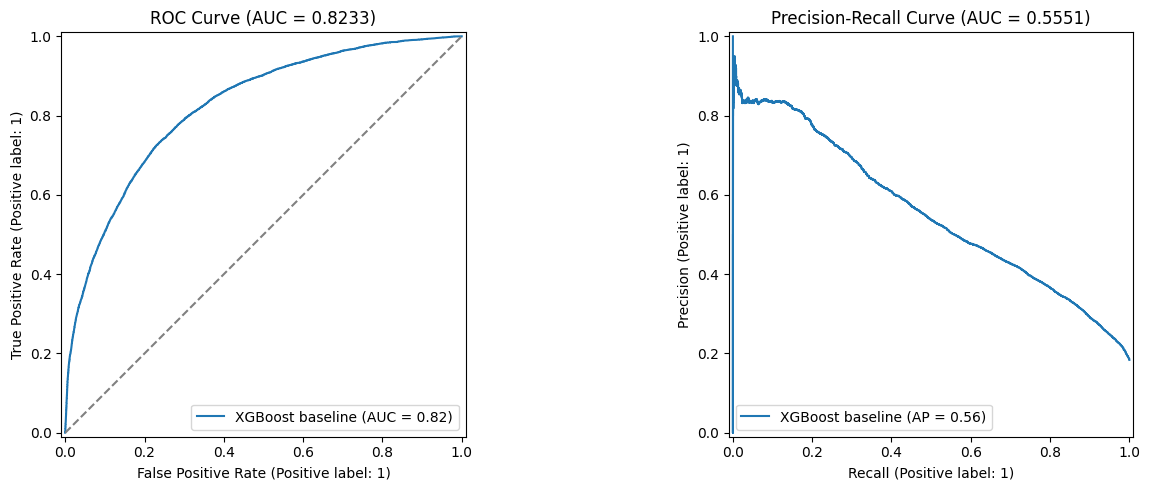

In [26]:
# ROC Curves and Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[0], name='XGBoost baseline')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0,1],[0,1], linestyle='--', color='grey')

PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[1], name='XGBoost baseline')
axes[1].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')

plt.tight_layout()
plt.show()

In [27]:
# Optimal threshold search prioritizing recall
# Clinical context: false negatives are more dangerous than false positives
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

# Filter thresholds where recall ≥ 0.80 and select the one with the highest precision
min_recall = 0.80
mask = recalls[:-1] >= min_recall

if mask.any():
    best_idx       = precisions[:-1][mask].argmax()
    best_threshold = thresholds[mask][best_idx]
    best_precision = precisions[:-1][mask][best_idx]
    best_recall    = recalls[:-1][mask][best_idx]
    print(f'Threshold óptimo (recall >= {min_recall}): {best_threshold:.3f}')
    print(f'  Precision: {best_precision:.4f}')
    print(f'  Recall:    {best_recall:.4f}')
else:
    print(f'No threshold was found meeting the recall criteria >= {min_recall}, adjust min_recall')

Threshold óptimo (recall >= 0.8): 0.489
  Precision: 0.3662
  Recall:    0.8003


In [28]:
# Classification report con el threshold óptimo
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print(f'Classification report (threshold={best_threshold:.3f}):\n')
print(classification_report(y_val, y_val_pred, target_names=['good control', 'poor control']))

Classification report (threshold=0.489):

              precision    recall  f1-score   support

good control       0.94      0.69      0.79     37862
poor control       0.37      0.80      0.50      8524

    accuracy                           0.71     46386
   macro avg       0.65      0.74      0.65     46386
weighted avg       0.83      0.71      0.74     46386



## 6. SHAP Analysis

SHAP (SHapley Additive exPlanations) allows us to understand **how much each feature contributes** to the prediction, both globally (average importance) and individually (per patient).

We use this for two purposes:
1. **Clinical interpretability:** which variables truly predict poor control
2. **Model pruning:** identify features with near-zero importance to remove them before tuning

In [29]:
import shap
import matplotlib.pyplot as plt

# We calculate SHAP values on the validation set (faster than training set, sufficiently representative)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (46386, 51)


In [30]:
# Global importance: mean of the absolute SHAP value per feature
# Sorted from highest to lowest importance
shap_importance = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(shap_importance.to_string())

                         feature  importance
0                       ics_laba    0.749889
1              poor_control_lag1    0.508620
2              poor_control_acum    0.345356
3         eos_level_no_analitics    0.221149
4                  ics_laba_lag1    0.163936
5                            age    0.104086
6    eos_level_lag1_no_analitics    0.085127
7                        ap_zone    0.059718
8                years_in_record    0.056750
9                     spirometry    0.037463
10              eos_level_normal    0.036591
11             allergy_follow_up    0.036408
12                       obesity    0.032611
13                       anxiety    0.032049
14                          area    0.031091
15                           sex    0.026559
16         pulmonology_follow_up    0.023445
17                    depression    0.017278
18   ige_level_lag1_no_analitics    0.017217
19        ige_level_no_analitics    0.014222
20        chronic_kidney_disease    0.013197
21    pulm

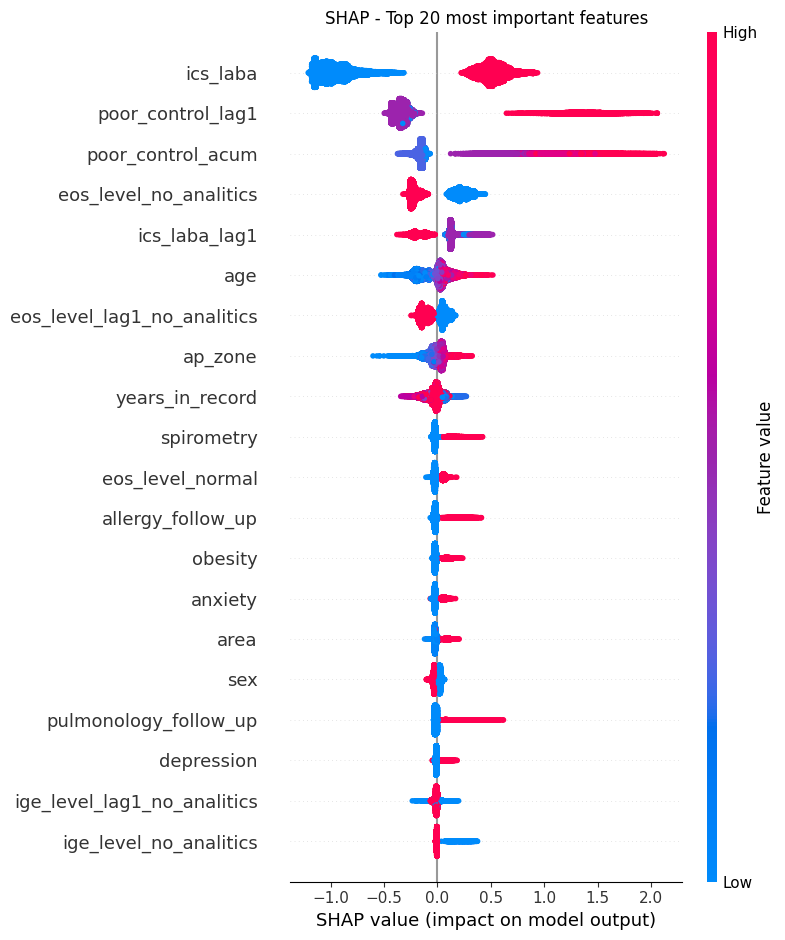

In [31]:
# Beeswarm plot: overall view of feature importance and effect direction
# Each point represents a patient, color = feature value, x-axis = impact on prediction
shap.summary_plot(shap_values, X_val, max_display=20, show=False)
plt.title('SHAP - Top 20 most important features')
plt.tight_layout()
plt.show()

In [32]:
# Identify features with near-zero importance (candidates for removal)
# Threshold: features whose importance is less than 1% of the most important feature
max_importance = shap_importance['importance'].max()
umbral         = max_importance * 0.01

bad_features = shap_importance[shap_importance['importance'] < umbral]

print(f'Umbral (1% of maximum): {umbral:.6f}')
print(f'Features with lowest importance: {len(bad_features)}')
print()
print(bad_features[['feature', 'importance']].to_string())

Umbral (1% of maximum): 0.007499
Features with lowest importance: 25

                      feature  importance
26              heart_failure    0.007046
27     allergy_follow_up_lag1    0.005215
28         eos_level_moderate    0.005176
29        eos_level_very_high    0.004695
30     cardiovascular_disease    0.004464
31             eos_level_high    0.004273
32        eos_level_lag1_high    0.003805
33    gastroesophageal_reflux    0.003047
34                   diabetes    0.003019
35                  feno_lag1    0.002480
36         biologic_treatment    0.002408
37            spirometry_lag1    0.002255
38                        osa    0.002236
39                 prick_test    0.001936
40                       feno    0.001752
41               osteoporosis    0.001593
42            prick_test_lag1    0.001394
43    biologic_treatment_lag1    0.001348
44    eos_level_lag1_moderate    0.001290
45        ige_level_lag1_high    0.001052
46   eos_level_lag1_very_high    0.000775
47    

## 7. Removal of Features with Zero Importance

After the SHAP analysis, we remove the 4 features with importance ≈ 0.
These correspond to the ‘sin_historial’ categories from one-hot encoding that do not provide information to the model.

They are removed from X_train, X_val and X_test, **not from the original dataframe**.

In [33]:
# Features with SHAP importance ≈ 0
drop_features = [
    'eos_level_lag1_no_history',
    'ige_level_lag1_no_history',
    'ige_level_lag1_normal',
    'ige_level_normal'
]

X_train = X_train.drop(columns=drop_features)
X_val   = X_val.drop(columns=drop_features)
X_test  = X_test.drop(columns=drop_features)

print(f'Shape after features deletion: {X_train.shape}')

Shape after features deletion: (209992, 47)


## 8. Hyperparameter Tuning with Optuna

We use Optuna to efficiently search for the best hyperparameters.
Unlike GridSearch, Optuna learns which regions of the search space are promising (Bayesian optimization) and focuses trials there.

Configuration:
- **150 trials**: exhaustive, leveraging the RTX 4050 with `device='cuda'`
- **Metric**: ROC-AUC on the validation set
- **Early stopping per trial**: avoids wasting time on poor combinations
- **Fixed `scale_pos_weight`**: not tuned, calculated from the data

In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) 

def objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 5),
        'min_child_weight':  trial.suggest_int('min_child_weight', 12, 20),
        'gamma':             trial.suggest_float('gamma', 0.3, 0.8),
        'n_estimators':      trial.suggest_int('n_estimators', 900, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.015, 0.05, log=True),
        'subsample':         trial.suggest_float('subsample', 0.70, 0.90),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.60, 0.80),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.50, 0.75),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.5, 3.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0001, 0.01, log=True),
        'scale_pos_weight':  scale_pos_weight,
        'eval_metric':       'auc',
        'device':            'cuda',
        'random_state':      42,
    }

    model_trial = XGBClassifier(**params, early_stopping_rounds=30)
    model_trial.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_proba = model_trial.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_proba)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f'\nBest ROC-AUC: {study.best_value:.4f}')
print(f'Best parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/150 [00:00<?, ?it/s]

/home/adilh/miniconda3/envs/ml-clinico/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [22:15:51] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Best ROC-AUC: 0.8241
Best parameters:
  max_depth: 5
  min_child_weight: 14
  gamma: 0.46332746440826694
  n_estimators: 1288
  learning_rate: 0.021012067188542823
  subsample: 0.8312759203670721
  colsample_bytree: 0.6767551174218276
  colsample_bylevel: 0.7247856569586644
  reg_alpha: 2.1469773158990058
  reg_lambda: 0.0026697202583285903


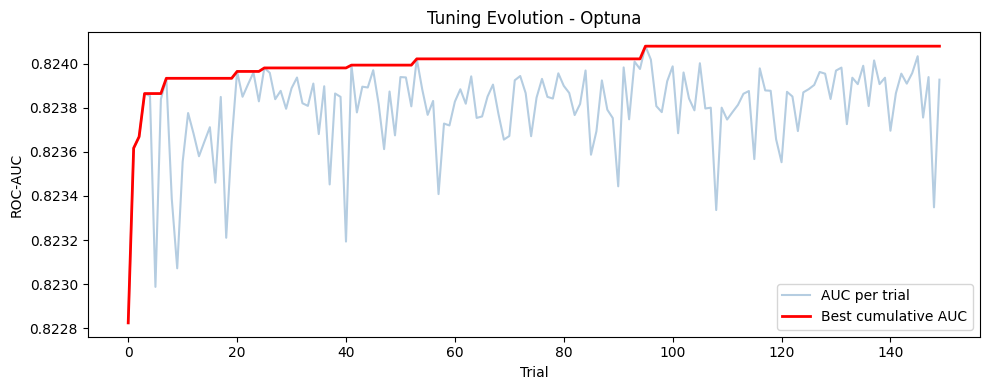

In [35]:
# Visualize the evolution of AUC across trials
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trial_values, alpha=0.4, label='AUC per trial', color='steelblue')
ax.plot(best_so_far,  label='Best cumulative AUC', color='red', linewidth=2)
ax.set_xlabel('Trial')
ax.set_ylabel('ROC-AUC')
ax.set_title('Tuning Evolution - Optuna')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
# Retrain the final model with the best hyperparameters
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'eval_metric':      'auc',
    'device':           'cuda',
    'random_state':     42,
})

model_tuned = XGBClassifier(**best_params, early_stopping_rounds=30)
model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f'\nTrees used: {model_tuned.best_iteration + 1}')

[0]	validation_0-auc:0.79456
[50]	validation_0-auc:0.81829
[100]	validation_0-auc:0.82028
[150]	validation_0-auc:0.82182
[200]	validation_0-auc:0.82260
[250]	validation_0-auc:0.82292
[300]	validation_0-auc:0.82320
[350]	validation_0-auc:0.82344
[400]	validation_0-auc:0.82364
[450]	validation_0-auc:0.82380
[500]	validation_0-auc:0.82391
[550]	validation_0-auc:0.82396
[600]	validation_0-auc:0.82404
[650]	validation_0-auc:0.82404
[653]	validation_0-auc:0.82405

Trees used: 624


In [37]:
# Evaluation of the tuned model on the validation set
y_val_proba_tuned = model_tuned.predict_proba(X_val)[:, 1]

roc_auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)
pr_auc_tuned  = average_precision_score(y_val, y_val_proba_tuned)

print(f'--- Baseline ---')
print(f'ROC-AUC:              {roc_auc:.4f}')
print(f'Precision-Recall AUC: {pr_auc:.4f}')
print()
print(f'--- Tuned ---')
print(f'ROC-AUC:              {roc_auc_tuned:.4f}')
print(f'Precision-Recall AUC: {pr_auc_tuned:.4f}')

--- Baseline ---
ROC-AUC:              0.8233
Precision-Recall AUC: 0.5551

--- Tuned ---
ROC-AUC:              0.8241
Precision-Recall AUC: 0.5583


In [38]:
# Optimal threshold for the tuned model
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_val, y_val_proba_tuned)

min_recall = 0.80
mask_t = recalls_t[:-1] >= min_recall

if mask_t.any():
    best_idx_t       = precisions_t[:-1][mask_t].argmax()
    best_threshold_t = thresholds_t[mask_t][best_idx_t]
    best_precision_t = precisions_t[:-1][mask_t][best_idx_t]
    best_recall_t    = recalls_t[:-1][mask_t][best_idx_t]
    print(f'Optimal Threshold (recall >= {min_recall}): {best_threshold_t:.3f}')
    print(f'  Precision: {best_precision_t:.4f}')
    print(f'  Recall:    {best_recall_t:.4f}')

y_val_pred_tuned = (y_val_proba_tuned >= best_threshold_t).astype(int)
print(f'\nClassification report (threshold={best_threshold_t:.3f}):\n')
print(classification_report(y_val, y_val_pred_tuned, target_names=['good control', 'poor control']))

Optimal Threshold (recall >= 0.8): 0.490
  Precision: 0.3648
  Recall:    0.8001

Classification report (threshold=0.490):

              precision    recall  f1-score   support

good control       0.94      0.69      0.79     37862
poor control       0.36      0.80      0.50      8524

    accuracy                           0.71     46386
   macro avg       0.65      0.74      0.65     46386
weighted avg       0.83      0.71      0.74     46386



## 9. Final Evaluation on Test

We evaluate the tuned model on the test set (year 2024), which has not been used at any point in the process.
This is the actual figure we would report as the model’s performance.

**Reminder:** the EDA showed that 2024 has a slightly higher poor control rate (~17.9%) compared to the training period average (~14.5%), so the model may find the test set slightly more challenging than validation.

In [39]:
# Test set predictions with the tuned model
y_test_proba = model_tuned.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_test_proba)
pr_auc_test  = average_precision_score(y_test, y_test_proba)

print('=== Final Comparison ===')
print(f"{'':25} {'Val':>10} {'Test':>10}")
print(f"{'ROC-AUC':25} {roc_auc_tuned:>10.4f} {roc_auc_test:>10.4f}")
print(f"{'PR-AUC':25} {pr_auc_tuned:>10.4f} {pr_auc_test:>10.4f}")

=== Final Comparison ===
                                 Val       Test
ROC-AUC                       0.8241     0.8195
PR-AUC                        0.5583     0.5344


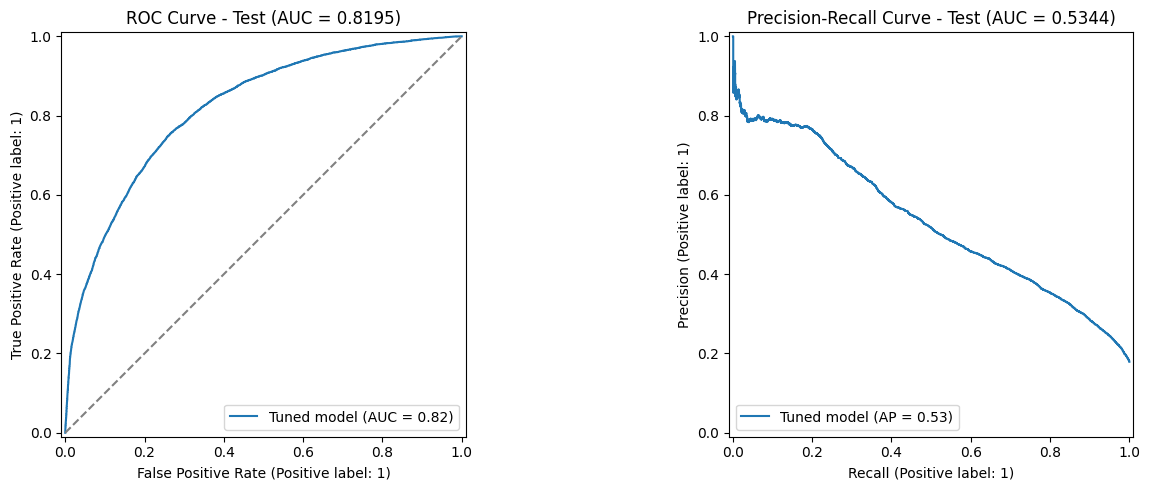

In [40]:
# ROC and Precision-Recall curves on the test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[0], name='Tuned model')
axes[0].set_title(f'ROC Curve - Test (AUC = {roc_auc_test:.4f})')
axes[0].plot([0,1],[0,1], linestyle='--', color='grey')

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=axes[1], name='Tuned model')
axes[1].set_title(f'Precision-Recall Curve - Test (AUC = {pr_auc_test:.4f})')

plt.tight_layout()
plt.show()

In [41]:
# We apply the same optimal threshold found on the validation set
y_test_pred = (y_test_proba >= best_threshold_t).astype(int)

print(f'Classification report - Test (threshold={best_threshold_t:.3f}):\n')
print(classification_report(y_test, y_test_pred, target_names=['good control', 'poor control']))

Classification report - Test (threshold=0.490):

              precision    recall  f1-score   support

good control       0.94      0.66      0.78     39491
poor control       0.34      0.82      0.48      8614

    accuracy                           0.69     48105
   macro avg       0.64      0.74      0.63     48105
weighted avg       0.84      0.69      0.72     48105



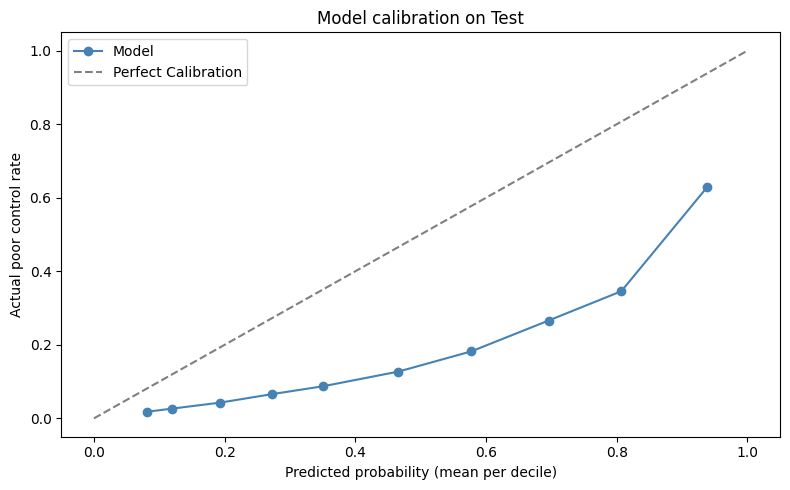

 decil  mean_prob  real_rate  count
     0   0.080929   0.017876   4811
     1   0.119391   0.026403   4810
     2   0.193407   0.042819   4811
     3   0.272668   0.065904   4810
     4   0.350718   0.087300   4811
     5   0.465598   0.127027   4810
     6   0.577472   0.182121   4810
     7   0.695844   0.266057   4811
     8   0.807151   0.345738   4810
     9   0.938731   0.629391   4811


In [42]:
# Calibration analysis: do the predicted probabilities reflect reality?
# We divide into probability deciles and compare predicted probability vs actual poor control rate
calibration_df = pd.DataFrame({
    'pred_proba': y_test_proba,
    'real':       y_test.values
})
calibration_df['decil'] = pd.qcut(calibration_df['pred_proba'], q=10, labels=False)

cal = calibration_df.groupby('decil').agg(
    mean_prob=('pred_proba', 'mean'),
    real_rate=('real', 'mean'),
    count=('real', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cal['mean_prob'], cal['real_rate'], 'o-', label='Model', color='steelblue')
ax.plot([0,1],[0,1], '--', color='grey', label='Perfect Calibration')
ax.set_xlabel('Predicted probability (mean per decile)')
ax.set_ylabel('Actual poor control rate')
ax.set_title('Model calibration on Test')
ax.legend()
plt.tight_layout()
plt.show()

print(cal.to_string(index=False))

## 10. Probability Calibration

XGBoost with `scale_pos_weight` discriminates well (AUC 0.82) but overestimates probabilities.
This is because rebalancing systematically inflates the raw probabilities.

We apply **isotonic calibration** on the validation set (`cv='prefit'`) to correct this.
This maps the inflated probabilities to actual probabilities without affecting the AUC.

It is a necessary step before clinical use: a doctor seeing “80% probability” should be able to interpret it literally.

In [43]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# In recent versions of scikit-learn, prefit is specified this way
calibrated_model = CalibratedClassifierCV(model_tuned, method='isotonic')
calibrated_model.estimator = model_tuned
calibrated_model.cv = 'prefit'

# More robust alternative if the above fails:
from sklearn.isotonic import IsotonicRegression

y_val_proba_tuned = model_tuned.predict_proba(X_val)[:, 1]
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(y_val_proba_tuned, y_val)

# Apply calibration manually on the test set
y_test_proba_cal = iso_reg.predict(y_test_proba)

roc_auc_cal = roc_auc_score(y_test, y_test_proba_cal)
pr_auc_cal  = average_precision_score(y_test, y_test_proba_cal)

print('=== Impact of calibration on Test ===')
print(f"{'Metric':<25} {'Without Calibration':>15} {'Calibrated':>15}")
print(f"{'ROC-AUC':<25} {roc_auc_test:>15.4f} {roc_auc_cal:>15.4f}")
print(f"{'PR-AUC':<25} {pr_auc_test:>15.4f} {pr_auc_cal:>15.4f}")

=== Impact of calibration on Test ===
Metric                    Without Calibration      Calibrated
ROC-AUC                            0.8195          0.8192
PR-AUC                             0.5344          0.5250


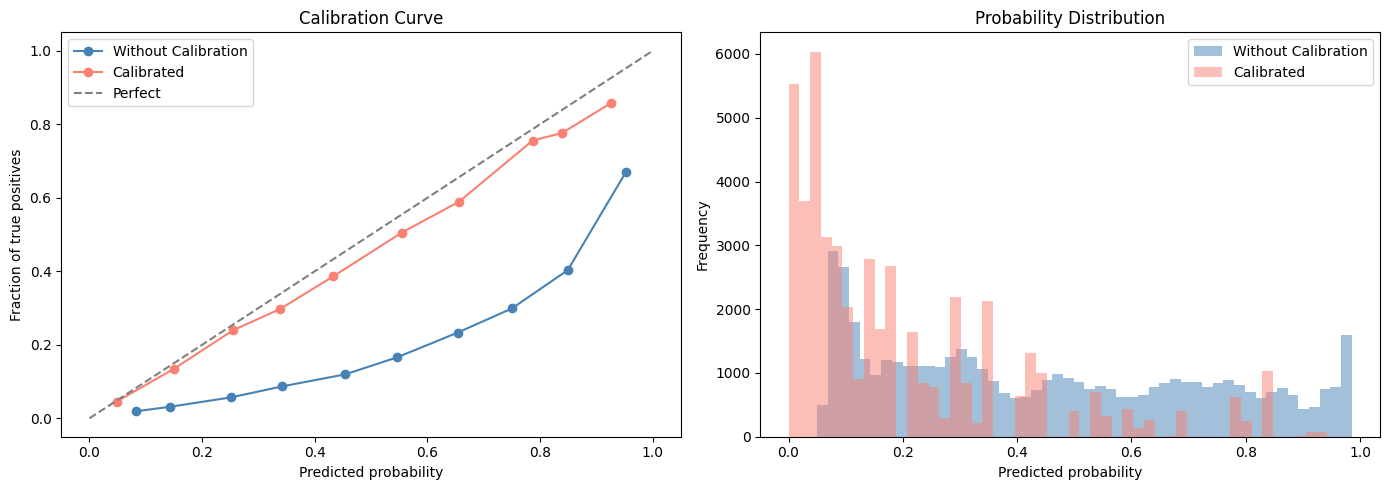

In [44]:
# Compare calibration before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de calibración
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_test_proba,     n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_test_proba_cal, n_bins=10)

axes[0].plot(mean_pred_raw, frac_pos_raw, 'o-', label='Without Calibration', color='steelblue')
axes[0].plot(mean_pred_cal, frac_pos_cal, 'o-', label='Calibrated',    color='salmon')
axes[0].plot([0,1],[0,1], '--', color='grey', label='Perfect')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Fraction of true positives')
axes[0].set_title('Calibration Curve')
axes[0].legend()

# Distribución de probabilidades antes y después
axes[1].hist(y_test_proba,     bins=50, alpha=0.5, label='Without Calibration', color='steelblue')
axes[1].hist(y_test_proba_cal, bins=50, alpha=0.5, label='Calibrated',    color='salmon')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# New optimal threshold after calibration
precisions_cal, recalls_cal, thresholds_cal = precision_recall_curve(y_test, y_test_proba_cal)

min_recall = 0.80
mask_cal   = recalls_cal[:-1] >= min_recall

if mask_cal.any():
    best_idx_cal       = precisions_cal[:-1][mask_cal].argmax()
    best_threshold_cal = thresholds_cal[mask_cal][best_idx_cal]
    best_precision_cal = precisions_cal[:-1][mask_cal][best_idx_cal]
    best_recall_cal    = recalls_cal[:-1][mask_cal][best_idx_cal]
    print(f'Optimal Threshold (recall >= {min_recall}): {best_threshold_cal:.3f}')
    print(f'  Precision: {best_precision_cal:.4f}')
    print(f'  Recall:    {best_recall_cal:.4f}')

y_test_pred_cal = (y_test_proba_cal >= best_threshold_cal).astype(int)
print(f'\nCalibrated classification report (threshold={best_threshold_cal:.3f}):\n')
print(classification_report(y_test, y_test_pred_cal, target_names=['good control', 'poor control']))

Optimal Threshold (recall >= 0.8): 0.139
  Precision: 0.3391
  Recall:    0.8262

Calibrated classification report (threshold=0.139):

              precision    recall  f1-score   support

good control       0.94      0.65      0.77     39491
poor control       0.34      0.83      0.48      8614

    accuracy                           0.68     48105
   macro avg       0.64      0.74      0.63     48105
weighted avg       0.84      0.68      0.72     48105



## 11. Model Saving

We save the 5 artifacts needed to fully reproduce the production pipeline:

| Artefacto | Contenido |
|-----------|----------|
| `model_tuned.pkl` | XGBoost model with optimal hyperparameters |
| `iso_reg.pkl` | Isotonic calibrator trained on validation |
| `model_calibrated.pkl` | Calibrated XGBoost model |
| `encoders.pkl` | Target encoders, OHE, removed features, and column order |
| `threshold.pkl` | Calibrated optimal threshold (recall ≥ 0.80) |

In [47]:
# Combined object: model + calibration in one (more convenient for production)
from sklearn.pipeline import Pipeline
import joblib
import pickle

class CalibratedXGB:
    """Wrapper that merges XGBoost + isotonic calibration in a single call."""
    def __init__(self, model, iso_reg):
        self.model   = model
        self.iso_reg = iso_reg

    def predict_proba(self, X):
        proba_raw = self.model.predict_proba(X)[:, 1]
        proba_cal = self.iso_reg.predict(proba_raw)
        return np.column_stack([1 - proba_cal, proba_cal])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

model_calibrated = CalibratedXGB(model_tuned, iso_reg)
joblib.dump(model_calibrated, 'models/model_calibrated.pkl')

['models/model_calibrated.pkl']

In [48]:
import os

os.makedirs('models', exist_ok=True)

# Tuned XGBoost model
joblib.dump(model_tuned, 'models/model_tuned.pkl')

# Isotonic calibrator
joblib.dump(iso_reg, 'models/iso_reg.pkl')

# Encoders and pipeline metadata
encoders = {
    'target_encoders': target_encoders,        # Mappings for area and ap_zone
    'ohe':             ohe,                    # OneHotEncoder for eos_level, ige_level, and their lags
    'global_mean':     global_mean,            # Global mean for categories unseen in training
    'ohe_cols':        ohe_cols,               # Columns to which OHE is applied
    'drop_features':   drop_features,          # Features removed after SHAP
    'features':        list(X_train.columns),  # Final feature order
}
joblib.dump(encoders, 'models/encoders.pkl')

# Calibrated optimal threshold (recall ≥ 0.80)
joblib.dump(best_threshold_cal, 'models/threshold.pkl')

print('Artifacts saved in models/:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  {f}: {size:.1f} KB')

Artifacts saved in models/:
  encoders.pkl: 6.6 KB
  iso_reg.pkl: 1.5 KB
  model_calibrated.pkl: 1649.8 KB
  model_tuned.pkl: 1648.4 KB
  threshold.pkl: 0.1 KB
